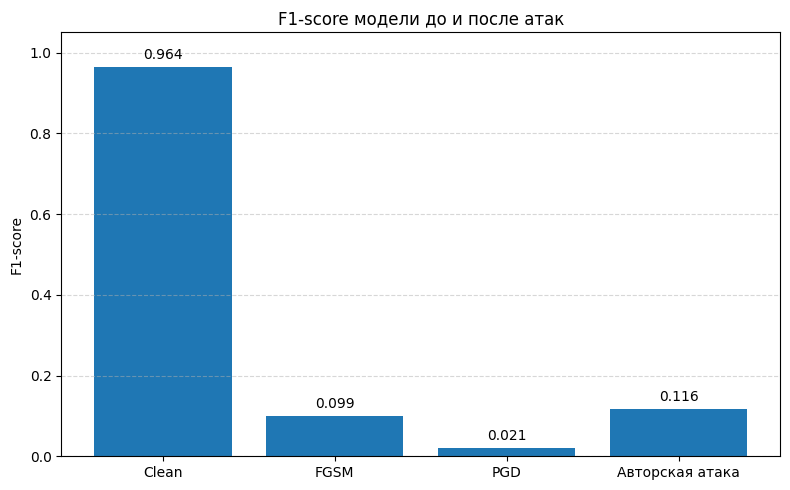

In [2]:
import matplotlib.pyplot as plt

labels = ["Clean", "FGSM", "PGD", "Авторская атака"]
f1 = [0.9640, 0.0986, 0.0210, 0.1159]

plt.figure(figsize=(8,5))
bars = plt.bar(labels, f1)
plt.ylim(0, 1.05)
plt.title("F1-score модели до и после атак")
plt.ylabel("F1-score")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
             f"{b.get_height():.3f}", ha="center")

plt.tight_layout()
plt.show()


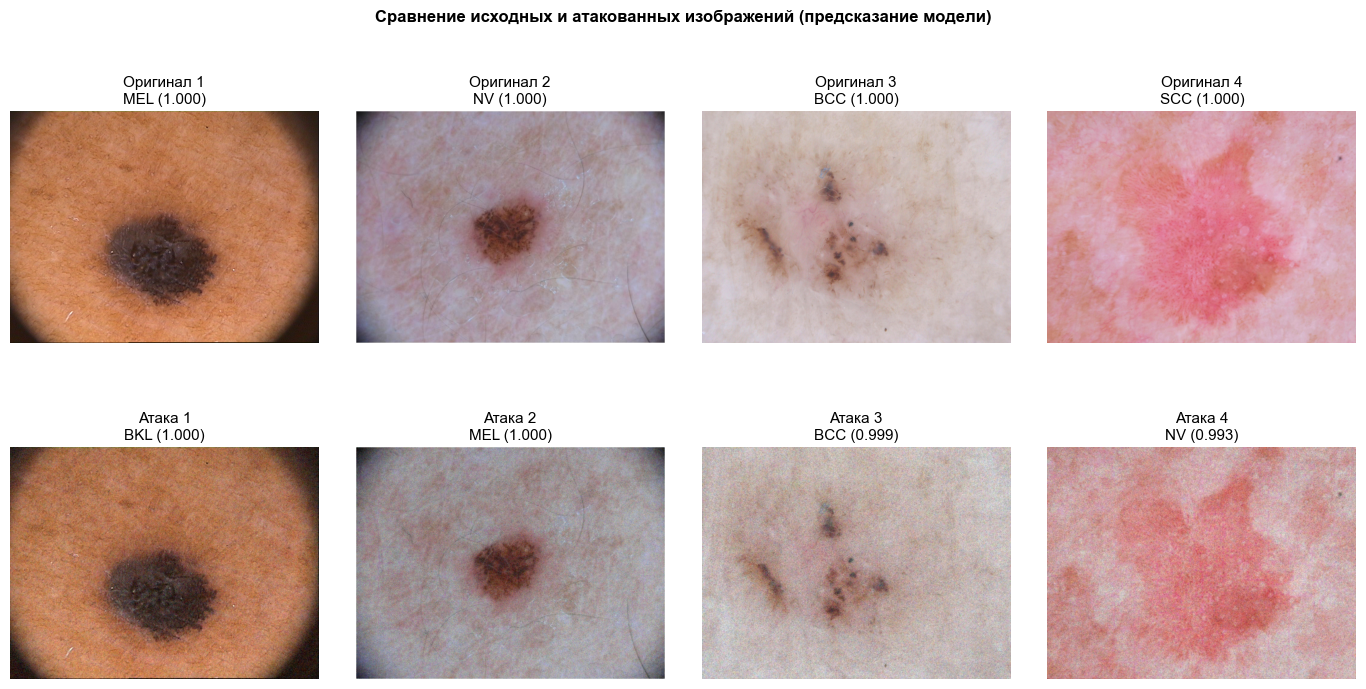

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification

# ПУТЬ К ЧЕКПОИНТУ:
MODEL_PATH = r"melanoma_attacks/checkpoint-12670"

device = "cuda" if torch.cuda.is_available() else "cpu"

# Грузим процессор и модель:
processor = AutoImageProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForImageClassification.from_pretrained(MODEL_PATH).to(device)
model.eval()

# НАСТРОЙКИ ИЗОБРАЖЕНИЙ:
original_images = [
    "balanced_Image/MEL/ISIC_0000298.jpg",
    "balanced_Image/NV/ISIC_0000012.jpg",
    "balanced_Image/BCC/ISIC_0025102.jpg",
    "balanced_Image/SCC/ISIC_0027506.jpg"
]
attacked_images = [
    "isic_1000_attacked/MEL/ISIC_0000298.jpg",
    "isic_1000_attacked/NV/ISIC_0000012.jpg",
    "isic_1000_attacked/BCC/ISIC_0025102.jpg",
    "isic_1000_attacked/SCC/ISIC_0027506.jpg"
]

# ФУНКЦИЯ ПРЕДСКАЗАНИЯ:
@torch.no_grad()
def predict_label_and_prob(img: Image.Image):
    inputs = processor(images=img, return_tensors="pt").to(device)
    logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=1)[0]
    pred_id = torch.argmax(probs).item()
    pred_label = model.config.id2label[pred_id]
    pred_prob = probs[pred_id].item()
    return pred_label, pred_prob

#ВИЗУАЛИЗАЦИЯ:
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'Arial'
})
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    # Оригиналы (RGB):
    orig_img = Image.open(original_images[i]).convert("RGB")
    orig_label, orig_prob = predict_label_and_prob(orig_img)
    axes[0, i].imshow(orig_img)
    axes[0, i].axis("off")
    axes[0, i].set_title(
        f"Оригинал {i+1}\n"
        f"{orig_label} ({orig_prob:.3f})",
        fontsize=11
    )
    # Атакованные (RGB):
    atk_img = Image.open(attacked_images[i]).convert("RGB")
    atk_label, atk_prob = predict_label_and_prob(atk_img)

    axes[1, i].imshow(atk_img)
    axes[1, i].axis("off")
    axes[1, i].set_title(
        f"Атака {i+1}\n"
        f"{atk_label} ({atk_prob:.3f})",
        fontsize=11
    )
fig.suptitle(
    "Сравнение исходных и атакованных изображений (предсказание модели)\n",
    fontsize=12, weight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.subplots_adjust(hspace=0.45)
plt.show()


Device: cuda


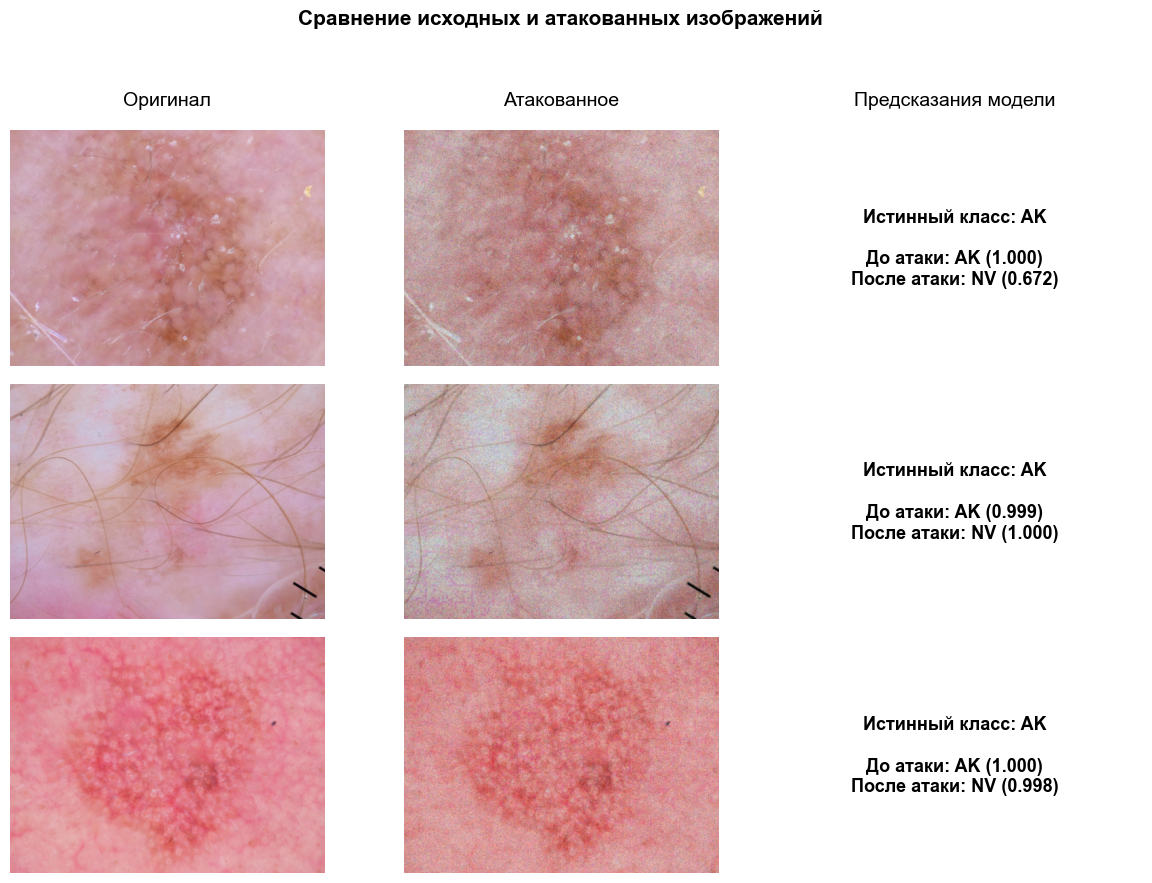

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification

# =========================
# НАСТРОЙКИ
# =========================
MODEL_PATH = "melanoma_attacks/checkpoint-12670"
CLEAN_ROOT = "balanced_Image"
ATTACKED_ROOT = "isic_1000_attacked"

CLASS_NAMES = ["AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"]

EXAMPLES = [
    ("AK", "ISIC_0026650.jpg"),
    ("AK", "ISIC_0026468.jpg"),
    ("AK", "ISIC_0028063.jpg"),
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ЗАГРУЗКА МОДЕЛИ
processor = ViTImageProcessor.from_pretrained(MODEL_PATH)
model = ViTForImageClassification.from_pretrained(MODEL_PATH).to(device)
model.eval()

if hasattr(model.config, "id2label") and model.config.id2label:
    id2label = {int(k): v for k, v in model.config.id2label.items()} if isinstance(list(model.config.id2label.keys())[0], str) else model.config.id2label
else:
    id2label = {i: cls for i, cls in enumerate(CLASS_NAMES)}

# ФУНКЦИЯ ПРЕДСКАЗАНИЯ:
@torch.no_grad()
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    outputs = model(pixel_values=pixel_values)
    probs = torch.softmax(outputs.logits, dim=1)[0]

    pred_idx = int(torch.argmax(probs).item())
    pred_label = id2label[pred_idx]
    pred_conf = float(probs[pred_idx].item())

    return pred_label, pred_conf

# ПОСТРОЕНИЕ ВСЕГО РИСУНКА:
plt.rcParams.update({
    "font.size": 12,
    "font.family": "Arial"
})

fig, axes = plt.subplots(len(EXAMPLES), 3, figsize=(12, 9))

if len(EXAMPLES) == 1:
    axes = [axes]

for row_idx, (true_class, filename) in enumerate(EXAMPLES):
    clean_path = os.path.join(CLEAN_ROOT, true_class, filename)
    attacked_path = os.path.join(ATTACKED_ROOT, true_class, filename)

    clean_img = Image.open(clean_path).convert("RGB")
    attacked_img = Image.open(attacked_path).convert("RGB")

    pred_clean, conf_clean = predict_image(clean_path)
    pred_attacked, conf_attacked = predict_image(attacked_path)

    # Оригинал
    axes[row_idx][0].imshow(clean_img)
    axes[row_idx][0].axis("off")
    if row_idx == 0:
        axes[row_idx][0].set_title("Оригинал", fontsize=14, pad=18)

    # Атакованное
    axes[row_idx][1].imshow(attacked_img)
    axes[row_idx][1].axis("off")
    if row_idx == 0:
        axes[row_idx][1].set_title("Атакованное", fontsize=14, pad=18)

    # Текстовая колонка
    text = (
        f"Истинный класс: {true_class}\n\n"
        f"До атаки: {pred_clean} ({conf_clean:.3f})\n"
        f"После атаки: {pred_attacked} ({conf_attacked:.3f})"
    )

    axes[row_idx][2].text(
        0.5, 0.5,
        text,
        fontsize=13,
        va="center",
        ha="center",
        weight="bold"
    )
    axes[row_idx][2].axis("off")

    if row_idx == 0:
        axes[row_idx][2].set_title("Предсказания модели", fontsize=14, pad=18)

fig.suptitle(
    "Сравнение исходных и атакованных изображений",
    fontsize=15,
    weight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()